<a href="https://colab.research.google.com/github/SawyerKaye/CYSE635/blob/main/CNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial libraries and image displaying (copied from course example)

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets
from torch.utils.data import Subset
from torch.autograd import Variable
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# define the function of displaying multiple images
def show_images(images) -> None:
    n: int = images.size(0)

    f = plt.figure(figsize=(24, 6))
    for i in range(n):
        # Debug, plot figure
        f.add_subplot(1, n, i + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.axis('off')

    plt.show(block=True)

# define the function of displaying multiple images
def show_images_withPred(images,label,pred,conf) -> None:
    n: int = images.size(0)

    f = plt.figure(figsize=(24, 6))
    for i in range(n):
        # Debug, plot figure
        f.add_subplot(1, n, i + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title("{} -> {}".format(label[i], pred[i]))
        #plt.title("Conf:{} \n {} -> {}".format(conf[i][pred[i]]*100,label[i], pred[i]))
        plt.axis('off')

    plt.show(block=True)

# Early Stop Class

Based off a GeeksForGeeks example, I implemented an early stop class for normalization. It takes in a patience and minimum delta variable and will be used to stop model training if model performance doesn't improve by at least the minimum delta amount after "patience" number of attempts.

In [28]:
class EarlyStop:
  def __init__(self, patience=5, min_delta=0):
    self.patience = patience # Setting initial values
    self.min_delta = min_delta
    self.BestLoss = None
    self.stop = False
    self.counter = 0
    self.BestModel = None

  def __call__(self, val_loss, model):
    if self.BestLoss is None: #Checks if early stop has been used yet, if not sets initial values
      self.BestLoss = -val_loss
      self.BestModel = model.state_dict()

    elif -val_loss > self.BestLoss - self.min_delta: #Checks if loss has improved by at least min_delta amount
      self.counter += 1 # if not, counter is incremented
      if(self.counter >= self.patience): # if number of consecutive trainings has not resulted in improved model performance, training is stopped
        self.stop = True

    else: #if model performance has improved, we take note of new best loss value and save the current model state
      self.BestLoss = -val_loss
      self.BestModel = model.state_dict()
      self.counter = 0

  def load_best_model(self, model): # loads best model after stop
    model.load_state_dict(self.BestModel)


Reference: https://www.geeksforgeeks.org/deep-learning/how-to-handle-overfitting-in-pytorch-models-using-early-stopping/

# Hyperparameters and Data Loading

Defining Hyperparameters, Learning Rate (lr), Batch Size, Number of Epochs for training, Number of Classes, patience and min_delta for Early Stop

In [29]:
lr = .001
batch_size = 250
num_epochs = 10
num_classes = 10
patience = 500
min_delta = 0

Applying basic data transformation (converting image to a tensor) and then loading the dataset into DataLoaders

In [30]:
transform = transforms.Compose([
    transforms.ToTensor()]) # transforming image to a Tensor

# Loading the dataset
train_dataset = torchvision.datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, transform=transform)

# Putting the dataset into a DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=2, shuffle=False)

# Implementing course CNN

I implemented the course CNN just to get better practice/understanding of the code, as well as to give me a tangible baseline for what accuracy/efficiency I should be striving for

In [31]:
from torch.nn.modules.conv import Conv2d
class MyNet(nn.Module):
  def __init__(self):
    super(MyNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.Linear(7*7*32, 120)
    self.fc2 = nn.Linear(120, 80)
    self.fc3 = nn.Linear(80,10)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

model = MyNet()
model.cuda()

MyNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): Linear(in_features=1568, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)

Establishing Loss Function and Optimizer

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Training the model

In [33]:
%%time
model.train()
loss_list_1=[]
acc_list_1=[]
total_step = len(train_loader)

#Training the model based on the Training Dataset
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()
    outputs = model(images)

    optimizer.zero_grad()

    loss = criterion(outputs, labels)
    loss_list_1.append(loss.item())

    loss.backward()
    optimizer.step()

    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted==labels).sum().item()
    acc_list_1.append(correct/total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))

Epoch [1/10], Step [0/240], Loss: 2.3028, Accuracy: 12.00%
Epoch [1/10], Step [150/240], Loss: 0.1590, Accuracy: 95.20%
Epoch [2/10], Step [0/240], Loss: 0.0866, Accuracy: 97.20%
Epoch [2/10], Step [150/240], Loss: 0.0613, Accuracy: 97.60%
Epoch [3/10], Step [0/240], Loss: 0.0384, Accuracy: 98.40%
Epoch [3/10], Step [150/240], Loss: 0.0346, Accuracy: 99.20%
Epoch [4/10], Step [0/240], Loss: 0.0445, Accuracy: 98.00%
Epoch [4/10], Step [150/240], Loss: 0.0421, Accuracy: 98.40%
Epoch [5/10], Step [0/240], Loss: 0.0315, Accuracy: 99.20%
Epoch [5/10], Step [150/240], Loss: 0.0919, Accuracy: 97.60%
Epoch [6/10], Step [0/240], Loss: 0.0627, Accuracy: 98.40%
Epoch [6/10], Step [150/240], Loss: 0.0380, Accuracy: 99.60%
Epoch [7/10], Step [0/240], Loss: 0.0268, Accuracy: 98.80%
Epoch [7/10], Step [150/240], Loss: 0.0346, Accuracy: 99.20%
Epoch [8/10], Step [0/240], Loss: 0.0235, Accuracy: 99.20%
Epoch [8/10], Step [150/240], Loss: 0.0448, Accuracy: 98.00%
Epoch [9/10], Step [0/240], Loss: 0.0143

Evaluating model accuracy

In [34]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 98.5 %


# My initial attempt at a CNN

I attempted to implement my own CNN, adding another convolutional layer before each pooling. Additionally, I used Lazy Linear from the PyTorch library to more easily implement my FCNs as I tried mulitple different shapes for my convolutional layers.

In [35]:
class MyNewNet(nn.Module):
  def __init__(self):
    super(MyNewNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=3, stride=1, padding=2),
        nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(16, 64, kernel_size=5, stride=1, padding=1),
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.LazyLinear(250)
    self.fc2 = nn.Linear(250, 100)
    self.fc3 = nn.Linear(100,10)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

model = MyNewNet()
model.cuda()

MyNewNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): LazyLinear(in_features=0, out_features=250, bias=True)
  (fc2): Linear(in_features=250, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

Initiliazing the Loss Function and Optimizer

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Training my CNN on the training dataset, printing the Loss and Accuracy half way through and at the end of each epoch

In [37]:
%%time
model.train()
loss_list_2=[] #Using Loss and accuracy lists to be able to plot later
acc_list_2=[]
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()
    outputs = model(images)

    optimizer.zero_grad()

    loss = criterion(outputs, labels)
    loss_list_2.append(loss.item())

    loss.backward()
    optimizer.step()

    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted==labels).sum().item()
    acc_list_2.append(correct/total)

    if (i%120 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))

Epoch [1/10], Step [0/240], Loss: 2.2976, Accuracy: 12.00%
Epoch [1/10], Step [120/240], Loss: 0.1375, Accuracy: 94.40%
Epoch [2/10], Step [0/240], Loss: 0.0235, Accuracy: 99.20%
Epoch [2/10], Step [120/240], Loss: 0.0508, Accuracy: 98.80%
Epoch [3/10], Step [0/240], Loss: 0.0315, Accuracy: 98.80%
Epoch [3/10], Step [120/240], Loss: 0.0666, Accuracy: 98.00%
Epoch [4/10], Step [0/240], Loss: 0.0170, Accuracy: 99.60%
Epoch [4/10], Step [120/240], Loss: 0.0362, Accuracy: 99.20%
Epoch [5/10], Step [0/240], Loss: 0.0742, Accuracy: 98.00%
Epoch [5/10], Step [120/240], Loss: 0.0188, Accuracy: 99.60%
Epoch [6/10], Step [0/240], Loss: 0.0127, Accuracy: 99.60%
Epoch [6/10], Step [120/240], Loss: 0.0173, Accuracy: 99.20%
Epoch [7/10], Step [0/240], Loss: 0.0458, Accuracy: 98.40%
Epoch [7/10], Step [120/240], Loss: 0.0423, Accuracy: 98.40%
Epoch [8/10], Step [0/240], Loss: 0.0135, Accuracy: 99.20%
Epoch [8/10], Step [120/240], Loss: 0.0284, Accuracy: 99.20%
Epoch [9/10], Step [0/240], Loss: 0.0336

Evaluating my model against the testing dataset

In [38]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 98.66 %


Plotting both course and my LeNet model's accuracy and loss against each other

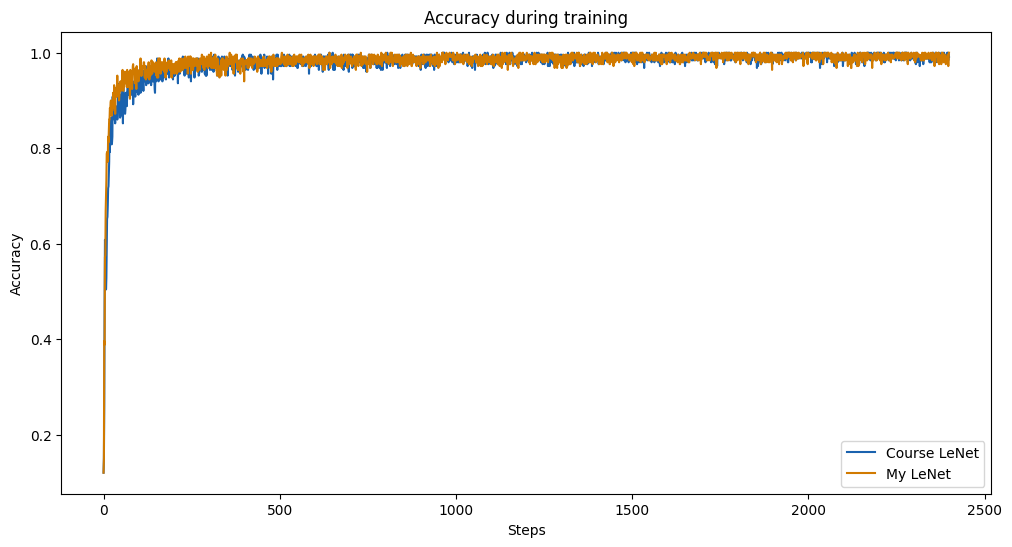

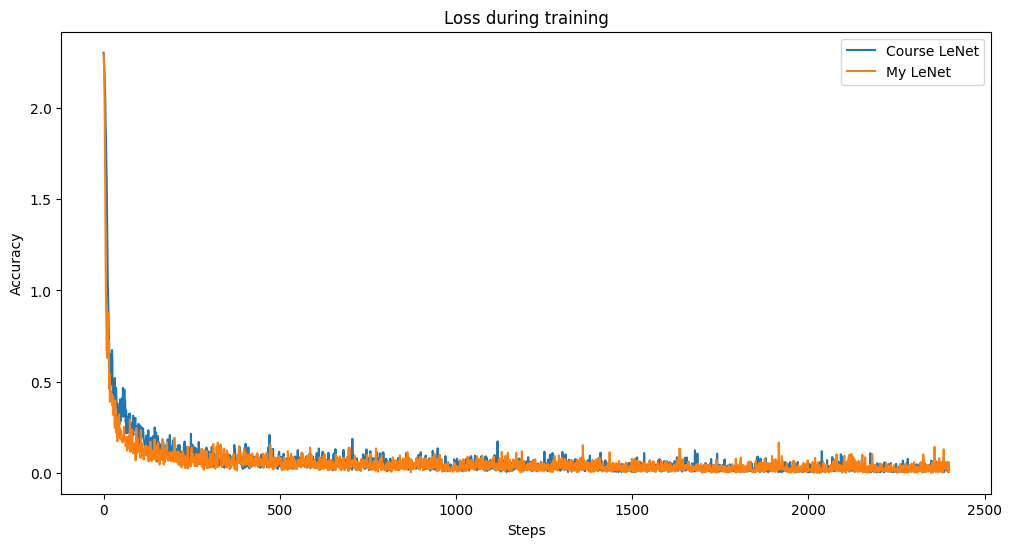

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(acc_list_1, color='#1A62AE')  # Course LeNet color: Blue
plt.plot(acc_list_2, color='#D17A00')  # My LeNet color: Orange
plt.legend(['Course LeNet', 'My LeNet'])
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy during training')
plt.show()


plt.figure(figsize=(12,6))
plt.plot(loss_list_1)
plt.plot(loss_list_2)
plt.legend(['Course LeNet','My LeNet'])
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.title('Loss during training')
plt.show()

# My Optimized LeNet

After trying to make a better version of the LeNet previously, I decided to implement a more robust version with 2 convolutional layers, followed by a max pooling layer, repeated twice with flattening at the end

After the first convolutional layer, I added in a Dropout layer, which will randomly zero out certain neurons in the network. This prevents overfitting as neurons cannot become dependent on one another

In [40]:
class MyNewNet(nn.Module):
  def __init__(self):
    super(MyNewNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=3, stride=1, padding=2),
        nn.Dropout(p=.1),
        nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(16, 64, kernel_size=5, stride=1, padding=1),
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.LazyLinear(250)
    self.fc2 = nn.Linear(250, 100)
    self.fc3 = nn.Linear(100,10)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

model = MyNewNet()
model.cuda()

MyNewNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): Dropout(p=0.1, inplace=False)
    (2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): LazyLinear(in_features=0, out_features=250, bias=True)
  (fc2): Linear(in_features=250, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)

Loss function and Optimizer initialized, with my Early Stop method also being used here

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
earlystop = EarlyStop(patience=750, min_delta=0)

Same training session as previous implementations, with the addition of Early Stopping to prevent overfitting

In [42]:
%%time
model.train()
loss_list_3=[]
acc_list_3=[]
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()
    outputs = model(images)

    optimizer.zero_grad()

    loss = criterion(outputs, labels)
    loss_list_3.append(loss.item())

    loss.backward()
    optimizer.step()

    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted==labels).sum().item()
    acc_list_3.append(correct/total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
    earlystop(loss, model)
    if earlystop.stop:
      print('Early Stopping')
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
      earlystop.load_best_model(model)
      break
  if earlystop.stop:
    break

Epoch [1/10], Step [0/240], Loss: 2.3117, Accuracy: 10.40%
Epoch [1/10], Step [150/240], Loss: 0.2026, Accuracy: 94.80%
Epoch [2/10], Step [0/240], Loss: 0.1586, Accuracy: 94.00%
Epoch [2/10], Step [150/240], Loss: 0.0924, Accuracy: 96.00%
Epoch [3/10], Step [0/240], Loss: 0.0501, Accuracy: 98.00%
Epoch [3/10], Step [150/240], Loss: 0.0555, Accuracy: 97.60%
Epoch [4/10], Step [0/240], Loss: 0.0188, Accuracy: 98.80%
Early Stopping
Epoch [4/10], Step [31/240], Loss: 0.0542, Accuracy: 98.00%
CPU times: user 6.39 s, sys: 409 ms, total: 6.8 s
Wall time: 23.4 s


Evaluating Model performance

In [43]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 98.24000000000001 %


Plotting model performance of my LeNet vs the Optimized LeNet

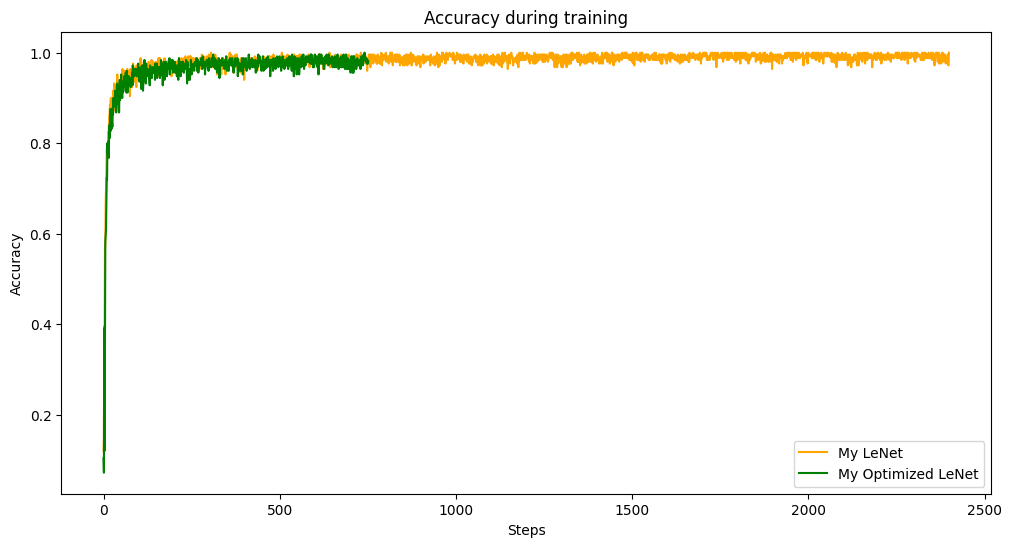

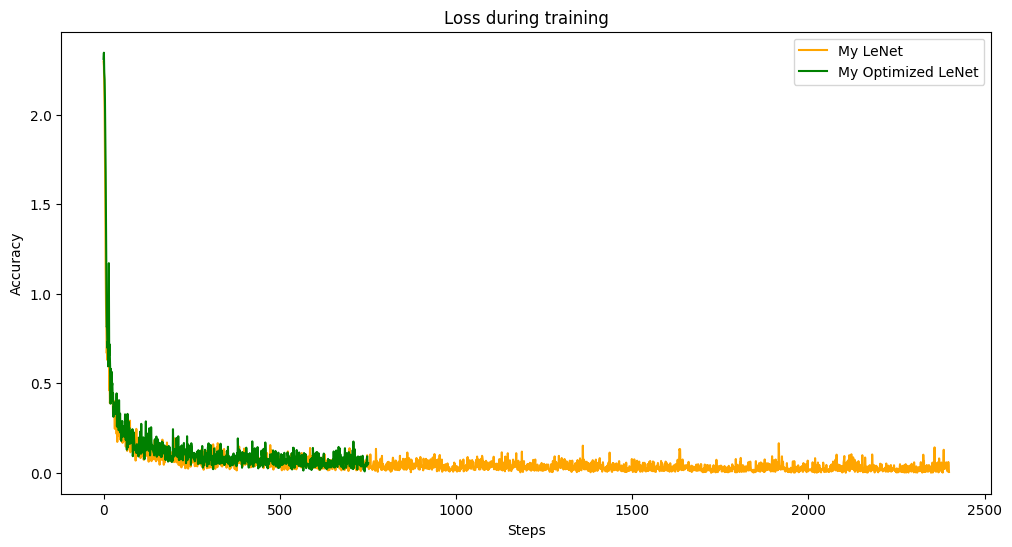

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(acc_list_2, color='orange')
plt.plot(acc_list_3, color='green')
plt.legend(['My LeNet', 'My Optimized LeNet'])
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy during training')
plt.show()


plt.figure(figsize=(12,6))
plt.plot(loss_list_2, color='orange')
plt.plot(loss_list_3, color='green')
plt.legend(['My LeNet','My Optimized LeNet'])
plt.xlabel('Steps')
plt.ylabel('Accuracy')
plt.title('Loss during training')
plt.show()

# Efficient Model Implementation

This Model draws insipiration from EfficientNet by utilizing Batch Normalizaiton and Rectified Linear Unit, though the model itself is much to simple to actually be following its architecture

In [45]:
class MyEfficientNet(nn.Module):
  def __init__(self):
    super(MyEfficientNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(),
        nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=1),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.LazyLinear(120)
    self.fc2 = nn.Linear(120, 80)
    self.fc3 = nn.Linear(80,10)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

model = MyEfficientNet()
model.cuda()

MyEfficientNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Flatten(start_dim=1, end_dim=-1)
  )
  (fc1): LazyLinear(in_features=0, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)

Establishing Loss function, Optimizer, and Early Stop

In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
earlystop = EarlyStop(patience=750, min_delta=0)

Training the model with Early Stop

In [47]:
%%time
model.train()
loss_list_4=[]
acc_list_4=[]
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    images = images.cuda()
    labels = labels.cuda()
    outputs = model(images)

    optimizer.zero_grad()

    loss = criterion(outputs, labels)
    loss_list_4.append(loss.item())

    loss.backward()
    optimizer.step()

    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted==labels).sum().item()
    acc_list_4.append(correct/total)

    if (i%150 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
    earlystop(loss, model)
    if earlystop.stop:
      print('Early Stopping')
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))
      earlystop.load_best_model(model)
      break
  if earlystop.stop:
    break

Epoch [1/10], Step [0/240], Loss: 2.3066, Accuracy: 10.40%
Epoch [1/10], Step [150/240], Loss: 0.1486, Accuracy: 96.40%
Epoch [2/10], Step [0/240], Loss: 0.0335, Accuracy: 98.80%
Epoch [2/10], Step [150/240], Loss: 0.0663, Accuracy: 98.40%
Epoch [3/10], Step [0/240], Loss: 0.1142, Accuracy: 96.80%
Epoch [3/10], Step [150/240], Loss: 0.0595, Accuracy: 98.80%
Epoch [4/10], Step [0/240], Loss: 0.0322, Accuracy: 98.80%
Early Stopping
Epoch [4/10], Step [30/240], Loss: 0.0412, Accuracy: 99.20%
CPU times: user 5.23 s, sys: 367 ms, total: 5.6 s
Wall time: 20.6 s


Evaluating the model

In [48]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for i, (images, labels) in enumerate(test_loader):
    images = images.cuda()
    labels = labels.cuda()

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the model on the 10000 test images: {} %'.format((correct / total) * 100))

Accuracy of the model on the 10000 test images: 98.57000000000001 %


Plotting the Efficient Model vs the Optimized Model

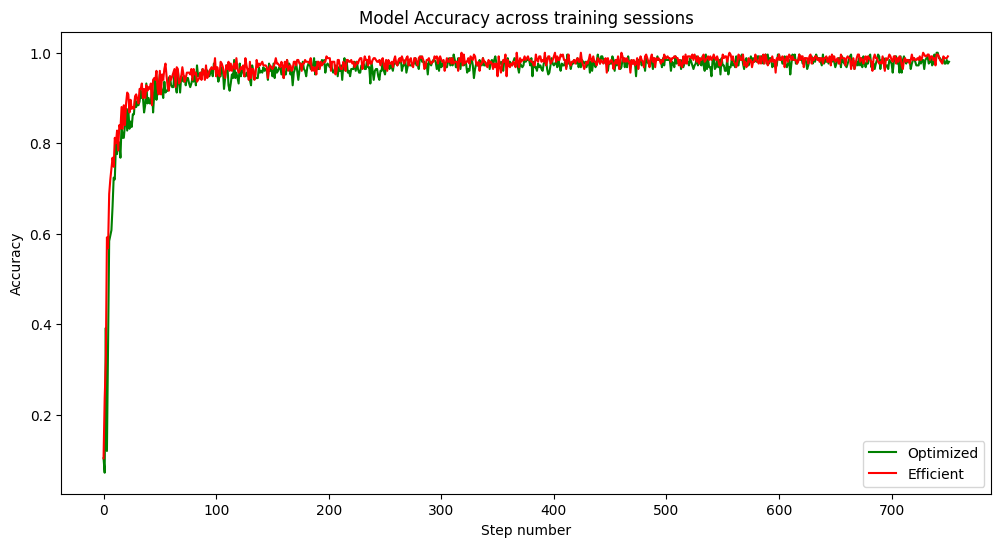

Text(0.5, 1.0, 'loss')

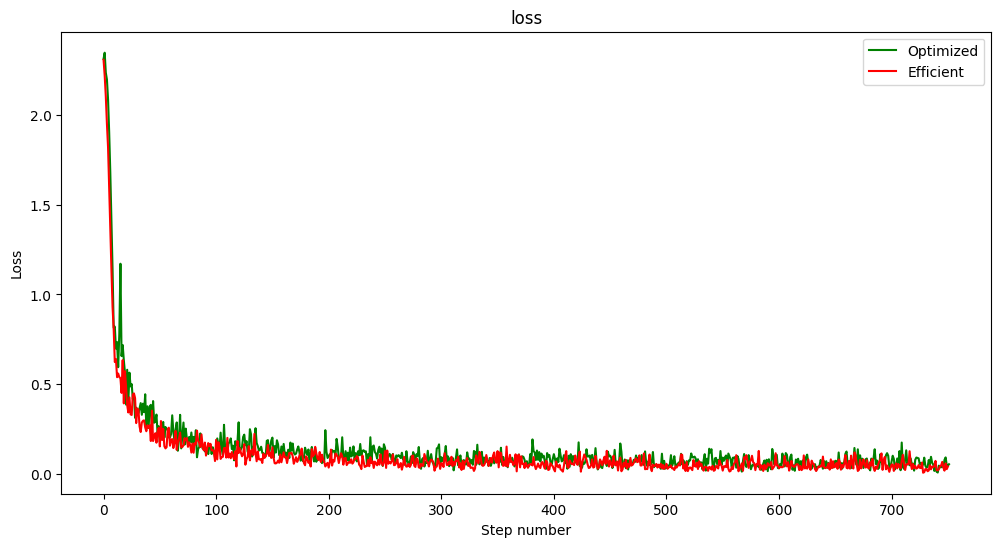

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(acc_list_3, color='green')
plt.plot(acc_list_4, color='red')
plt.legend(['Optimized', 'Efficient'])
plt.xlabel('Step number')
plt.ylabel('Accuracy')
plt.title('Model Accuracy across training sessions')
plt.show()


plt.figure(figsize=(12,6))
plt.plot(loss_list_3, 'green')
plt.plot(loss_list_4, 'red')
plt.legend(['Optimized','Efficient'])
plt.xlabel('Step number')
plt.ylabel('Loss')
plt.title('Model Loss across training sessions')
plt.title('loss')

# Overall Graphs

Plotting model accuracy/loss for all models

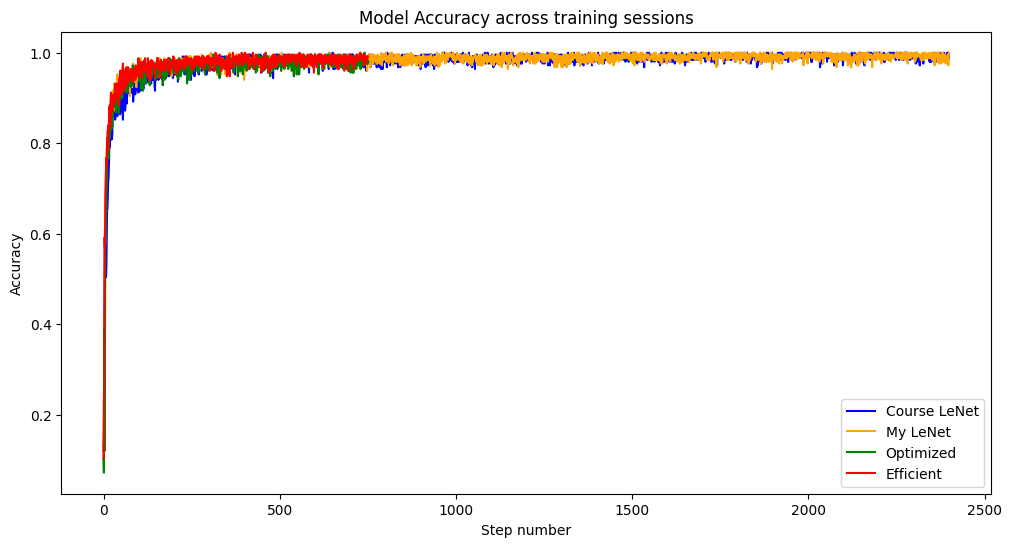

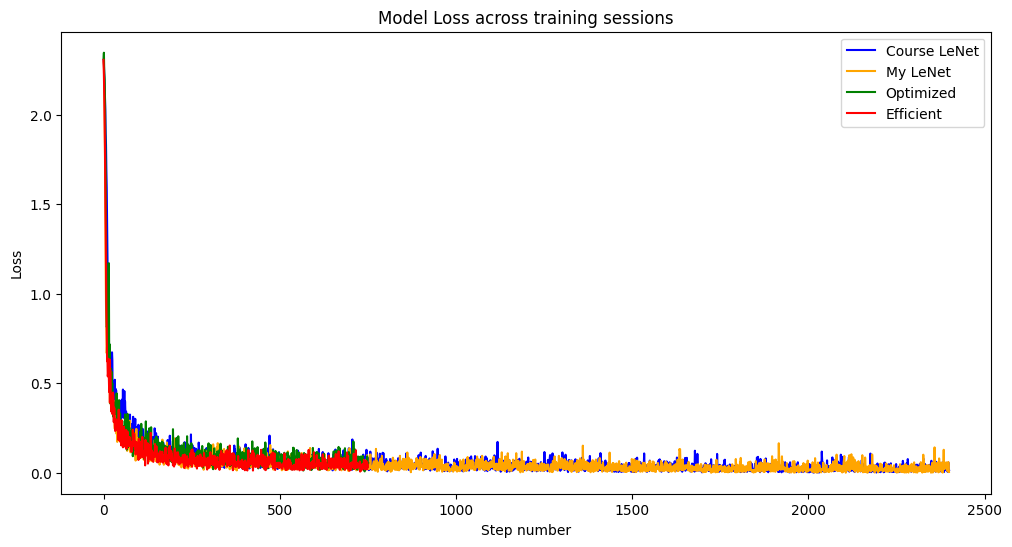

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(acc_list_1, color='blue')
plt.plot(acc_list_2, color='orange')
plt.plot(acc_list_3, color='green')
plt.plot(acc_list_4, color='red')
plt.legend(['Course LeNet', 'My LeNet', 'Optimized', 'Efficient'])
plt.xlabel('Step number')
plt.ylabel('Accuracy')
plt.title('Model Accuracy across training sessions')
plt.show()


plt.figure(figsize=(12,6))
plt.plot(loss_list_1, color='blue')
plt.plot(loss_list_2, 'orange')
plt.plot(loss_list_3, 'green')
plt.plot(loss_list_4, 'red')
plt.legend(['Course LeNet', 'My LeNet', 'Optimized', 'Efficient'])
plt.xlabel('Step number')
plt.ylabel('Loss')
plt.title('Model Loss across training sessions')
plt.show()

Plotting Model performance in CPU time

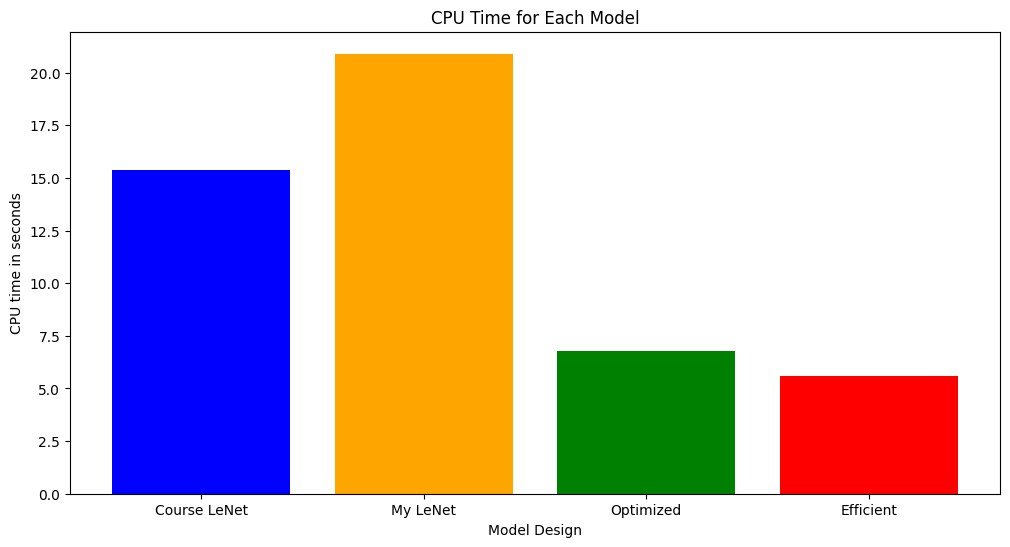

In [52]:
cpu_times = [15.4, 20.9, 6.8, 5.6]
plt.figure(figsize=(12,6))
plt.bar(height=cpu_times, x=['Course LeNet', 'My LeNet', 'Optimized', 'Efficient'], color=['blue', 'orange', 'green', 'red'])
plt.ylabel('CPU time in seconds')
plt.xlabel('Model Design')
plt.title('CPU Time for Each Model')
plt.show()